In [ ]:
from micrograd.nn import MLP
import random
from plot_utils import plot_points, plot_decision_boundary

In [29]:
def make_blobs(n_samples, noise=0.2, seed=42):
    rng = random.Random(seed)
    data = []
    for i in range(n_samples):
        label = i % 2
        if label == 0:
            cx, cy = -1.0, -1.0
        else:
            cx, cy = 1.0, 1.0
        x = cx + rng.gauss(0.0, noise)
        y = cy + rng.gauss(0.0, noise)
        data.append(([x, y], float(label)))
    rng.shuffle(data)
    return data

train_data = make_blobs(200, noise=0.25, seed=42)
test_data = make_blobs(60, noise=0.25, seed=123)


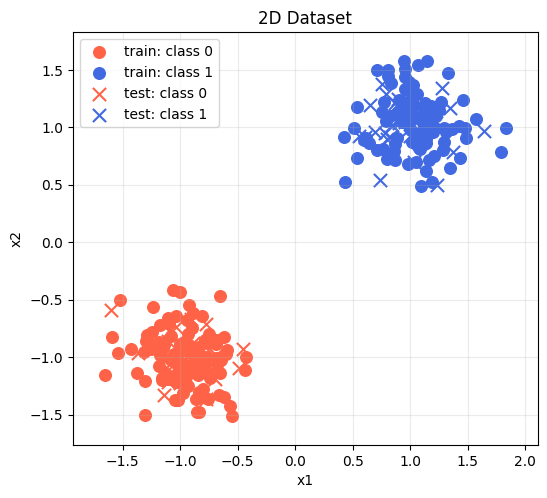

In [30]:
plot_points(train_data, test_data)

In [37]:
random.seed(42)

xs = [x for x, y in train_data]
ys = [float(y) for x, y in train_data]
xs_test = [x for x, y in test_data]
ys_test = [float(y) for x, y in test_data]

mlp = MLP(2, [1])


In [38]:
def train(mlp, xs, ys, epochs=200, lr=0.01):
    for i in range(epochs):
        # Forward pass
        ypreds = [mlp(x) for x in xs]
        loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, ys)) * (1.0 / len(xs))

        # Backward pass
        for p in mlp.parameters():
            p.grad = 0.0
        loss.backward()

        # Gradient step
        for p in mlp.parameters():
            p.data += -lr * p.grad

        if i % 10 == 0 or i == epochs - 1:
            print(f"Epoch {i:4d} | loss: {loss.data:.4f}")

train(mlp, xs, ys)


Epoch    0 | loss: 1.7190
Epoch   10 | loss: 0.8117
Epoch   20 | loss: 0.4101
Epoch   30 | loss: 0.2282
Epoch   40 | loss: 0.1429
Epoch   50 | loss: 0.1010
Epoch   60 | loss: 0.0792
Epoch   70 | loss: 0.0670
Epoch   80 | loss: 0.0597
Epoch   90 | loss: 0.0549
Epoch  100 | loss: 0.0516
Epoch  110 | loss: 0.0491
Epoch  120 | loss: 0.0472
Epoch  130 | loss: 0.0455
Epoch  140 | loss: 0.0441
Epoch  150 | loss: 0.0429
Epoch  160 | loss: 0.0418
Epoch  170 | loss: 0.0407
Epoch  180 | loss: 0.0397
Epoch  190 | loss: 0.0388
Epoch  199 | loss: 0.0380


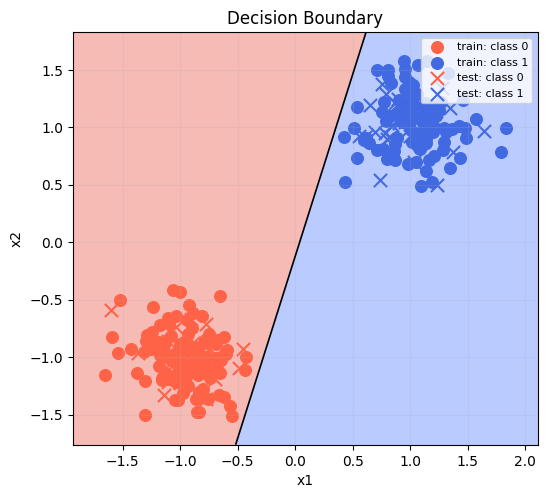

In [39]:
plot_decision_boundary(mlp, train_data, test_data)